# Identification of a 2-DOF Mass-Spring-Damper System with Output-Only Data

***

* [Theoretical Background](#theoretical-background)
    * [MIMO Fundamental Theorem](#mimo-fundamental)
    * [White Noise Excitation and Modal Decomposition](#white-noise)
    * [Rational Fraction Polynomial Method for PSDs](#rfp-psd)
* [Parameter Estimation from Output-Only Measurements](#estimation-output-only)
    * [Data Generation](#data-generation)
    * [Output PSD Calculation](#psd-calculation)
    * [Parameter Estimation with Fixed Model Order](#parameter-estimation-fixed)
    * [Parameter Estimation with Multiple Model Orders](#parameter-estimation-multiple)
* [Comparison with Input-Output Analysis](#comparison)
* [Conclusions](#conclusions)

## Theoretical Background <a name="theoretical-background"></a>

***

### MIMO Fundamental Theorem

In operational modal analysis, we measure only the responses of a structure under ambient or operational excitation, without measuring the input forces. To understand how we can extract modal parameters from output-only data, we must first understand the relationship between input and output spectral characteristics of a Multiple-Input Multiple-Output (MIMO) Linear Time-Invariant (LTI) system, which is described by the MIMO fundamental theorem.

Consider a LTI MIMO system with $N$ degrees of freedom, excited by a vector of random forces $\mathbf{x}(t)$ and producing a vector of responses $\mathbf{y}(t)$ (where the dimensions of the two vectors do not have to match). The system is characterized by its impulse response matrix $\mathbf{H}(t)$ and the input-output relationship in the time domain is given by the convolution:

$$\mathbf{y}(t) = \mathbf{H}(t) * \mathbf{x}(t) = \int_{-\infty}^{\infty} \mathbf{H}(\tau)\mathbf{x}(t-\tau)d\tau.$$

Taking the Laplace transform of both sides, we get the input-output relationship in the Laplace domain:

$$\tilde{\mathbf{y}}(s) = \tilde{\mathbf{H}}(s)\tilde{\mathbf{x}}(s),$$

where $\tilde{\mathbf{H}}(s)$ is the transfer function matrix.

The frequency domain relationship is obtained by taking the Fourier transform of the time domain relationship or by evaluating the Laplace domain relationship at $s = j\omega$, where $j$ is the imaginary unit and $\omega$ is the angular frequency, with $\tilde{\mathbf{H}}(j\omega)$ being the Frequency Response Function (FRF) matrix.

For random signals, we work with statistical quantities rather than deterministic time histories. The **correlation function matrix** of the responses is defined as:

$$\mathbf{R}_y(\tau) = E[\mathbf{y}(t)\mathbf{y}^\intercal(t+\tau)],$$

where $^\intercal$ denotes transpose and $E[\cdot]$ denotes the expected value (statistical average). The correlation function describes how the response at one time relates to the response at a later time, shifted by lag $\tau$.

In classic probability theory, the expected value $E[\mathbf{y}(t)\mathbf{y}^\intercal(t+\tau)]$ is calculated using the **ensemble average**, which requires the knowledge of the probability density function of each response. However, if the response signals are stationary, meaning that their probability density functions do not change over time, we can instead use the time average to estimate the expected value and thus the correlation function:

$$\mathbf{R}_y(\tau) = \lim_{T \to \infty} \frac{1}{T} \int_{0}^{T} \mathbf{y}(t)\mathbf{y}^\intercal(t+\tau) dt.$$

Time averaging is assumed to be identical to ensemble averaging for $T \to \infty$, which is known as the **ergodic hypothesis**. In practice, this means measuring response signals over a sufficiently long period of time.

The **spectral density matrix** is the Fourier transform of the correlation function:

$$\mathbf{G}_y(\omega) = \mathcal{F}\left(\mathbf{R}_y(\tau)\right) = \frac{1}{2\pi}\int_{-\infty}^{\infty} \mathbf{R}_y(\tau)e^{-j\omega\tau}d\tau.$$

The spectral density describes how the energy of the random signal is distributed across frequencies. By Parseval's theorem, the area under the spectral density equals the variance (mean square value) of the signal.

The **MIMO fundamental theorem** relates the input and output spectral density matrices through the FRF matrix:

$$\mathbf{G}_y(\omega) = \tilde{\mathbf{H}}^*(j\omega)\mathbf{G}_x(\omega)\tilde{\mathbf{H}}^\intercal(j\omega),$$

where $^*$ denotes complex conjugation. The MIMO fundamental theorem tells us that the spectral content of the output signals depends on:
1. The spectral content of the input excitation $\left(\mathbf{G}_x(\omega)\right)$
2. How the system transforms these inputs through its dynamics $\left(\tilde{\mathbf{H}}(j\omega)\right)$

The presence of both $\tilde{\mathbf{H}}(j\omega)^*$ and $\tilde{\mathbf{H}}^\intercal(j\omega)$ in the equation reflects the fact that we're computing second-order statistics (correlations or power spectral densities), which involve products of signals.

We remind that for the MIMO fundamental theorem to hold, we require:
1. The system is linear and time-invariant (superposition principle applies and system properties do not change over time)
2. The input and output signals are stationary processes (statistical properties do not change over time)
3. The input and output signals are ergodic processes (time averages equal ensemble averages)

### White Noise Excitation and Modal Decomposition

The key enabler for output-only modal analysis is the ***central limit theorem*** (CLT), which states that the sum of many independent and identically distributed random variables will tend to be Gaussian distributed as the number of variables approaches infinity. The strength of this theorem is that the Gaussian distribution is approached regardless of the type of distributions of the individual random variables in the linear combination.

The CLT is the reason why, in output-only modal analysis, the unmeasured excitation is modeled as **white noise**. White noise is a random signal $x(t)$ with property:

$$E[x(t_1)x(t_2)] = \begin{cases} \sigma^2 & \text{if } t_1 = t_2 \\ 0 & \text{if } t_1 \neq t_2 \end{cases},$$

where $\sigma$ is the standard deviation of the signal. The above property means that $x(t_1)$ and $x(t_2)$ are uncorrelated, which implies that they are independent. Consequently, for a linear system excited by white noise (independent input values), the CLT ensures the response is approximately Gaussian, regardless of the input's distribution, because the response is a sum of many independent terms from the convolution integral. The beauty of working with Gaussian distributed responses is that they are fully characterized by their second-order statistics. This is what justifies the use of correlation functions and spectral densities in OMA techniques.

White noise has equal energy at all frequencies within the band of interest, meaning its spectral density matrix is constant. Thus, by assuming the input excitation is white noise, we have:

$$\mathbf{G}_x(\omega) = \mathbf{C},$$

where $\mathbf{C}$ is a constant, real, symmetric, positive-definite matrix related to the covariance of the excitation forces.

Ambient excitation and operational forces often have broad-band characteristics, and while they're not truly white, they can be reasonably approximated as white over the frequency range of interest for modal identification. In addition, the CLT can be extended to weakly dependent random variables under certain conditions, which further supports the white noise assumption in practical scenarios. However, it's important to note that the more the actual excitation deviates from white noise, the more correlation will exist in the input, which will degrade the validity of working with correlation functions and spectral densities and thus the accuracy of the identified modal parameters.

Under the white noise assumption, the MIMO fundamental theorem simplifies to:

$$\mathbf{G}_y(\omega) = \tilde{\mathbf{H}}^*(j\omega)\mathbf{C}\tilde{\mathbf{H}}^\intercal(j\omega).$$

This is a powerful result because:

1. The output PSD depends only on system properties (through $\tilde{\mathbf{H}}$) and a constant scaling matrix ($\mathbf{C}$).
2. All modal information is contained in $\tilde{\mathbf{H}}$, which appears explicitly in the equation.
3. We can extract modal parameters from output measurements alone, without knowing the actual input forces.

Since $\mathbf{C}$ is constant, it only scales the output PSD and does not affect the frequencies of resonant peaks or the shapes of the spectral peaks, which are determined solely by the system's FRF matrix.

From the last notebook, we know that for a linear MDOF system with $N$ modes,the FRF matrix can be expressed in partial fraction form as:

$$\mathbf{H}(j\omega) = \sum_{n=1}^{N}\left(\frac{\mathbf{R}_n}{j\omega - \lambda_n} + \frac{\mathbf{R}_n^*}{j\omega - \lambda_n^*}\right),$$

where $\lambda_n = -\zeta_n\omega_n \pm j\omega_n\sqrt{1-\zeta_n^2}$ are the system poles (complex conjugate pairs) and $\mathbf{R}_n$ are the residue matrices.

Substituting the partial fraction form into the fundamental theorem with white noise input, we get:

$$\mathbf{G}_y(\omega) = \sum_{n=1}^{N}\left(\frac{\mathbf{R}_n}{-j\omega - \lambda_n} + \frac{\mathbf{R}_n^*}{-j\omega - \lambda_n^*}\right)\mathbf{C}\sum_{n=1}^{N}\left(\frac{\mathbf{R}_n}{j\omega - \lambda_n} + \frac{\mathbf{R}_n^*}{j\omega - \lambda_n^*}\right)^\intercal.$$

After some algebraic manipulation using partial fraction decomposition, we arrive at the **modal decomposition of the output PSD matrix**:

$$\mathbf{G}_y(\omega) = \sum_{n=1}^{N}\left(\frac{\mathbf{R}_n\mathbf{C}\mathbf{B}_n}{-j\omega-\lambda_n} + \frac{\mathbf{R}^*_n\mathbf{C}\mathbf{B}^*_n}{-j\omega-\lambda^*_n} + \frac{\mathbf{B}_n\mathbf{C}\mathbf{R}_n}{j\omega-\lambda_n} + \frac{\mathbf{B}^*_n\mathbf{C}\mathbf{R}^*_n}{j\omega-\lambda^*_n}\right),$$

where the matrix $\mathbf{B}_n$ is a weighted sum of the residual matrices:

$$\mathbf{B}_n = \sum_{s=1}^{N} \left(\frac{\mathbf{R}_s}{-\lambda_n - \lambda_s} + \frac{\mathbf{R}^*_s}{-\lambda_n - \lambda^*_s}\right).$$

The above result shows that the response PSD matrix has a rational fraction form similar to the FRF, but with four terms per mode instead of two. We also notice that the response PSD has poles at $\pm\lambda_n$ and $\pm\lambda_n^*$ for each system pole $\lambda_n$. This means the PSD has four poles per mode instead of the two poles per mode that the FRF has.

To find the relationship between PSD poles and system poles, we consider the least common denominator of the PSD expression for a single mode $n$:

$$(-j\omega - \lambda_n)(-j\omega - \lambda_n^*)(j\omega - \lambda_n)(j\omega - \lambda_n^*).$$

We notice that:

$$(-j\omega - \lambda_n)(j\omega - \lambda_n) = -(j\omega)^2 + \lambda_n^2 = \omega^2 + \lambda_n^2$$

$$(-j\omega - \lambda_n^*)(j\omega - \lambda_n^*) = \omega^2 + (\lambda_n^*)^2$$

Therefore, the denominator factor for mode $n$ is:

$$(\omega^2 + \lambda_n^2)(\omega^2 + (\lambda_n^*)^2).$$

If we use the square of the Laplace variable $s^2=(j\omega)^2=-\omega^2$, we can find the poles $\mu_n, \mu_n^*$ of the response PSD in the $s^2$ domain:

$$s^2 = \mu_n = \lambda_n^2 \quad \text{and} \quad s^2 = \mu_n^* = (\lambda_n^*)^2,$$

which means that the system poles are:

$$\lambda_n = \pm\sqrt{\mu_n} \quad \text{and} \quad \lambda_n^* = \pm\sqrt{\mu_n^*}.$$

We need to select the poles with negative real parts (stable poles) and positive imaginary parts (by convention) to obtain the physical system poles.

### Rational Fraction Polynomial Method for PSDs

Having established that the output PSD can be expressed as a ratio of polynomials in $s^2 = (j\omega)^2$, we can apply the RFP method from notebook 4, but now to PSDs instead of FRFs.

For each output DOF $i$ we model the corresponding element of the PSD matrix as a ratio of polynomials in $s^2 = (j\omega)^2$:

$$G_i(s^2) = \frac{\sum_{k=0}^{m} a_{i,k} (s^2)^k}{\sum_{k=0}^{n} b_k (s^2)^k}$$

where:
- $i$ indexes the different PSD functions
- $a_{i,k}$ are the numerator polynomial coefficients (different for each PSD function)
- $b_k$ are the denominator polynomial coefficients (common to all PSD functions)
- $m$ is the numerator order
- $n$ is the denominator order (note: **twice** the number of system modes)

To find the polynomial coefficients that best fit the measured PSD data, we minimize the error between the analytical RFP model and the measured PSDs.

Rearranging the RFP equation by multiplying both sides by the denominator and setting the highest denominator coefficient $b_{n} = 1$ (normalization):

$$\sum_{k=0}^{m} a_{i,k} (s^2)^k = G_i(s^2) \left( \sum_{k=0}^{n-1} b_k (s^2)^k + (s^2)^{n} \right)$$

Define the error at the $l$-th frequency point $\omega_l$ (where $s_l^2 = (j\omega_l)^2$) for the $i$-th PSD function as:

$$e_{i,l} = \sum_{k=0}^{m} a_{i,k} (s_l^2)^k - G_{i,l} \left( \sum_{k=0}^{n-1} b_k (s_l^2)^k + (s_l^2)^{n} \right)$$

where $G_{i,l} = G_i(\omega_l)$ is the measured PSD value at frequency $\omega_l$.

For all $L$ frequency points, we can write this in matrix form. For a single PSD function $i$:

$$\{\mathbf{e}_i\} = [\mathbf{P}]\{\mathbf{a}_i\} - [\mathbf{T}_i]\{\mathbf{b}\} - \{\boldsymbol{\omega}_i\}$$

where:
- $\{\mathbf{e}_i\}$ is the $L \times 1$ error vector
- $[\mathbf{P}]$ is the $L \times (m+1)$ matrix with elements $P_{lk} = (s_l^2)^k$
- $\{\mathbf{a}_i\}$ is the $(m+1) \times 1$ vector of numerator coefficients for PSD function $i$
- $[\mathbf{T}_i]$ is the $L \times n$ matrix with elements $T_{i,lk} = G_{i,l}(s_l^2)^k$
- $\{\mathbf{b}\}$ is the $n \times 1$ vector of denominator coefficients (common to all PSDs)
- $\{\boldsymbol{\omega}_i\}$ is the $L \times 1$ vector with elements $\omega_{i,l} = G_{i,l}(s_l^2)^{n}$

For a MIMO system with $N$ output DOFs, we measure $N$ auto-spectral density functions (one per DOF). We can then apply a global approach (analogous to GRFP), where we stack all the equations for $i = 1, 2, \ldots, N$:

$$\begin{bmatrix}
\{\mathbf{e}_1\} \\
\{\mathbf{e}_2\} \\
\vdots \\
\{\mathbf{e}_{N}\}
\end{bmatrix} = 
\begin{bmatrix}
[\mathbf{P}] & [\mathbf{0}] & \cdots & [\mathbf{0}] & -[\mathbf{T}_1] \\
[\mathbf{0}] & [\mathbf{P}] & \cdots & [\mathbf{0}] & -[\mathbf{T}_2] \\
\vdots & \vdots & \ddots & \vdots & \vdots \\
[\mathbf{0}] & [\mathbf{0}] & \cdots & [\mathbf{P}] & -[\mathbf{T}_{N}]
\end{bmatrix}
\begin{bmatrix}
\{\mathbf{a}_1\} \\
\{\mathbf{a}_2\} \\
\vdots \\
\{\mathbf{a}_{N}\} \\
\{\mathbf{b}\}
\end{bmatrix}
-
\begin{bmatrix}
\{\boldsymbol{\omega}_1\} \\
\{\boldsymbol{\omega}_2\} \\
\vdots \\
\{\boldsymbol{\omega}_{N}\}
\end{bmatrix}$$

In compact form:

$$\{\mathbf{e}\} = [\mathbf{A}]\{\mathbf{X}\} - \{\mathbf{B}\},$$

where $\{\mathbf{e}\}$ is the $\left(L \cdot N\right) \times 1$ error vector, $[\mathbf{A}]$ is a $\left(L \cdot N\right) \times \left(N(m+1) + n\right)$ matrix assembled from the $[\mathbf{P}]$ and $[\mathbf{T}_i]$ matrices, $\{\mathbf{X}\}$ is the $\left(N(m+1) + n\right) \times 1$ vector containing all numerator coefficients and the common denominator coefficients, and $\{\mathbf{B}\}$ is the $\left(L \cdot N\right) \times 1$ vector containing all $\{\boldsymbol{\omega}_i\}$ vectors.

This is an **overdetermined system** (many more equations than unknowns) that we solve in a least-squares sense.

The total sum of squared errors is:

$$E = \{\mathbf{e}\}^\intercal\{\mathbf{e}\} = ([\mathbf{A}]\{\mathbf{X}\} - \{\mathbf{B}\})^\intercal([\mathbf{A}]\{\mathbf{X}\} - \{\mathbf{B}\})$$

Expanding this expression:

$$E = \{\mathbf{X}\}^\intercal[\mathbf{A}]^\intercal[\mathbf{A}]\{\mathbf{X}\} - 2\{\mathbf{X}\}^\intercal[\mathbf{A}]^\intercal\{\mathbf{B}\} + \{\mathbf{B}\}^\intercal\{\mathbf{B}\}$$

To minimize $E$, we take the derivative with respect to $\{\mathbf{X}\}$ and set it to zero:

$$\frac{\partial E}{\partial \{\mathbf{X}\}} = 2[\mathbf{A}]^\intercal[\mathbf{A}]\{\mathbf{X}\} - 2[\mathbf{A}]^\intercal\{\mathbf{B}\} = \mathbf{0}$$

This yields the **normal equations**:

$$[\mathbf{A}]^\intercal[\mathbf{A}]\{\mathbf{X}\} = [\mathbf{A}]^\intercal\{\mathbf{B}\}$$

The normal equations $[\mathbf{A}]^\intercal[\mathbf{A}]\{\mathbf{X}\} = [\mathbf{A}]^\intercal\{\mathbf{B}\}$ can suffer from numerical issues:

1. **Ill-conditioning**: The matrix $[\mathbf{A}]^\intercal[\mathbf{A}]$ may be poorly conditioned, especially for high polynomial orders
2. **Amplified errors**: Forming $[\mathbf{A}]^\intercal[\mathbf{A}]$ squares the condition number
3. **Loss of rank**: Numerical round-off can cause loss of effective rank

To address these issues, we use **Singular Value Decomposition (SVD)** to solve the system more robustly.

The SVD of $[\mathbf{A}]$ is:

$$[\mathbf{A}] = [\mathbf{U}][\mathbf{\Sigma}][\mathbf{V}]^\intercal$$

where:
- $[\mathbf{U}]$ is a $(L \cdot N) \times (L \cdot N)$ orthogonal matrix ($[\mathbf{U}]^\intercal[\mathbf{U}] = [\mathbf{I}]$)
- $[\mathbf{V}]$ is a $(N(m+1) + n) \times (N(m+1) + n)$ orthogonal matrix
- $[\mathbf{\Sigma}]$ is $(L \cdot N) \times (N(m+1) + n)$ diagonal matrix with singular values $\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r > 0$

Starting from the normal equations:

$$[\mathbf{A}]^\intercal[\mathbf{A}]\{\mathbf{X}\} = [\mathbf{A}]^\intercal\{\mathbf{B}\}$$

Substitute the SVD decomposition $[\mathbf{A}] = [\mathbf{U}][\mathbf{\Sigma}][\mathbf{V}]^\intercal$:

$$([\mathbf{U}][\mathbf{\Sigma}][\mathbf{V}]^\intercal)^\intercal([\mathbf{U}][\mathbf{\Sigma}][\mathbf{V}]^\intercal)\{\mathbf{X}\} = ([\mathbf{U}][\mathbf{\Sigma}][\mathbf{V}]^\intercal)^\intercal\{\mathbf{B}\}$$

Using the transpose property $([\mathbf{ABC}])^\intercal = [\mathbf{C}]^\intercal[\mathbf{B}]^\intercal[\mathbf{A}]^\intercal$:

$$[\mathbf{V}][\mathbf{\Sigma}]^\intercal[\mathbf{U}]^\intercal[\mathbf{U}][\mathbf{\Sigma}][\mathbf{V}]^\intercal\{\mathbf{X}\} = [\mathbf{V}][\mathbf{\Sigma}]^\intercal[\mathbf{U}]^\intercal\{\mathbf{B}\}$$

Since $[\mathbf{U}]^\intercal[\mathbf{U}] = [\mathbf{I}]$:

$$[\mathbf{V}][\mathbf{\Sigma}]^\intercal[\mathbf{\Sigma}][\mathbf{V}]^\intercal\{\mathbf{X}\} = [\mathbf{V}][\mathbf{\Sigma}]^\intercal[\mathbf{U}]^\intercal\{\mathbf{B}\}$$

Pre-multiply both sides by $[\mathbf{V}]^\intercal$:

$$[\mathbf{\Sigma}]^\intercal[\mathbf{\Sigma}][\mathbf{V}]^\intercal\{\mathbf{X}\} = [\mathbf{\Sigma}]^\intercal[\mathbf{U}]^\intercal\{\mathbf{B}\}$$

The matrix $[\mathbf{\Sigma}]^\intercal[\mathbf{\Sigma}]$ is diagonal with elements $\sigma_i^2$. We can invert this (excluding small singular values):

$$[\mathbf{V}]^\intercal\{\mathbf{X}\} = ([\mathbf{\Sigma}]^\intercal[\mathbf{\Sigma}])^{-1}[\mathbf{\Sigma}]^\intercal[\mathbf{U}]^\intercal\{\mathbf{B}\}$$

Define the **pseudo-inverse** of $[\mathbf{\Sigma}]$ as $[\mathbf{\Sigma}]^{\dagger}$ with elements:

$$\Sigma_{ik}^{\dagger} = \begin{cases}
1/\sigma_i & \text{if } i=k \text{ and } \sigma_i > \epsilon \\
0 & \text{otherwise}
\end{cases}$$

where $\epsilon$ is a small tolerance (e.g., $\epsilon = 10^{-10} \times \sigma_{\max}$).

Then:

$$([\mathbf{\Sigma}]^\intercal[\mathbf{\Sigma}])^{-1}[\mathbf{\Sigma}]^\intercal = [\mathbf{\Sigma}]^{\dagger}$$

Therefore:

$$[\mathbf{V}]^\intercal\{\mathbf{X}\} = [\mathbf{\Sigma}]^{\dagger}[\mathbf{U}]^\intercal\{\mathbf{B}\}$$

Pre-multiplying by $[\mathbf{V}]$:

$$\boxed{\{\mathbf{X}\} = [\mathbf{V}][\mathbf{\Sigma}]^{\dagger}[\mathbf{U}]^\intercal\{\mathbf{B}\}}$$

This is the **SVD solution** to the least squares problem. 

**Advantages of SVD:**

1. **No explicit formation of** $[\mathbf{A}]^\intercal[\mathbf{A}]$: Avoids squaring the condition number
2. **Automatic regularization**: Small singular values can be excluded
3. **Rank detection**: The number of significant singular values indicates the effective rank
4. **Numerical stability**: More robust than direct matrix inversion

Once we have the denominator coefficients $\{\mathbf{b}\} = [b_0, b_1, \ldots, b_{n-1}, b_{n}]^\intercal$ (with $b_{n} = 1$), we form the denominator polynomial:

$$D(s^2) = (s^2)^{n} + b_{n-1}(s^2)^{n-1} + \cdots + b_1 s^2 + b_0$$

The **poles in the $s^2$ domain** are found by solving:

$$D(s^2) = 0$$

This yields $n$ roots $\mu_1, \mu_2, \ldots, \mu_{n}$, which are the PSD poles.

For each root $\mu_n$, we compute:

$$\lambda_n = \sqrt{\mu_n},$$

which are the poles in the $s$ domain, where:

$$\lambda_n = -\zeta_n \omega_n + j\omega_n \sqrt{1-\zeta_n^2}$$

From these poles we extract the modal parameters:

$$\omega_n = |\lambda_n|$$

$$\zeta_n = -\frac{\text{Re}(\lambda_n)}{|\lambda_n|}$$

## Parameter Estimation from Output-Only Measurements <a name="estimation-output-only"></a>

***

### Data Generation <a name="data-generation"></a>

True System Parameters:
Natural frequencies: [23.11178905 61.19013804] rad/s
Damping ratios: [0.14836852 0.06993401]
Mode shapes:
[[ 0.06440893+0.59570367j -0.129175  -0.65284851j]
 [ 0.16821498+0.78274667j -0.06377968+0.74366309j]]



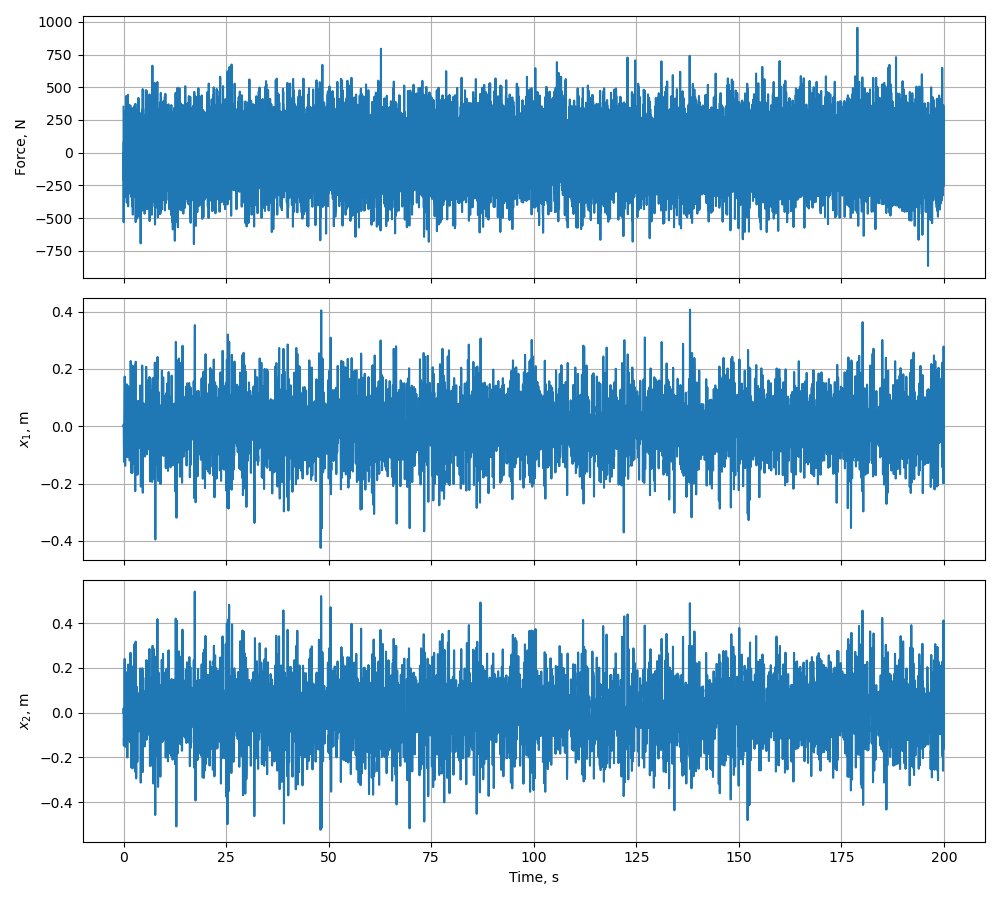

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal, linalg
from scipy.integrate import odeint
from scipy.interpolate import interp1d

# Enable interactive plots
%matplotlib widget

# Get default matplotlib colors
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Define number of degrees of freedom
N_DOFS = 2

# Define system parameters (same as notebook 6)
m_1 = 6  # mass 1 [kg]
k_1 = 6000  # stiffness constant 1 [N/m]
m_2 = 4  # mass 2 [kg]
k_2 = 8000  # stiffness constant 2 [N/m]

# Define mass and stiffness matrices
M = np.array([[m_1, 0], [0, m_2]])
K = np.array([[k_1 + k_2, -k_2], [-k_2, k_2]])

# Define non-proportional damping matrix
c_1 = 90.0  # [Ns/m]
c_2 = 1.0  # [Ns/m]
C = np.array([[c_1 + c_2, -c_2], [-c_2, c_2]])


def two_dof_mass_spring_damper(state, t, force):
    """
    Define system dynamics: dq/dt = f(q, t)
    
    Parameters:
    state (array): [displacement 1, displacement 2, velocity 1, velocity 2]
    t (float): Time
    force (function): External force signal, inputted as a function
    
    Returns:
    array: State derivatives [velocity 1, velocity 2, acceleration 1, acceleration 2]
    """
    # Unpack state variables
    x1, x2, x1dot, x2dot = state
    
    # Calculate accelerations
    x1ddot = (
        -(
            K[0, 0] * x1
            + K[0, 1] * x2
            + C[0, 0] * x1dot
            + C[0, 1] * x2dot
        )
        / M[0, 0]
    )
    x2ddot = (
        force(t)
        - (
            K[1, 0] * x1
            + K[1, 1] * x2
            + C[1, 0] * x1dot
            + C[1, 1] * x2dot
        )
        / M[1, 1]
    )
    
    return [x1dot, x2dot, x1ddot, x2ddot]


# Calculate true modal parameters for comparison
A_state = np.block([[C, M], [M, np.zeros((N_DOFS, N_DOFS))]])
B_state = np.block([[K, np.zeros((N_DOFS, N_DOFS))], [np.zeros((N_DOFS, N_DOFS)), -M]])

eigenvalues, eigenvectors = linalg.eig(-B_state, A_state)
natural_frequencies_true = np.abs(eigenvalues)

# Sort and extract physical poles
sorted_indices = np.argsort(natural_frequencies_true)
natural_frequencies_true = natural_frequencies_true[sorted_indices[::2]]
eigenvectors = eigenvectors[:N_DOFS, sorted_indices[::2]]

# Calculate damping ratios
damping_ratios_true = (
    -np.real(eigenvalues[sorted_indices[::2]]) / natural_frequencies_true
)

# Normalize mode shapes
mode_shapes_true = eigenvectors / np.linalg.norm(eigenvectors, axis=0)

print("True System Parameters:")
print(f"Natural frequencies: {natural_frequencies_true} rad/s")
print(f"Damping ratios: {damping_ratios_true}")
print(f"Mode shapes:\n{mode_shapes_true}\n")


# Generate response data
t_span = 200  # [s]
f_sampling = 100  # sampling frequency [Hz]
t_vector = np.arange(0, t_span, 1 / f_sampling)

# Generate random force signal
np.random.seed(11)
force_rms = 200  # RMS of the force signal [N]
random_signal = np.random.normal(size=len(t_vector))
random_force_signal = random_signal * (force_rms / np.sqrt(np.mean(random_signal**2)))

# Create interpolated force function
random_force_function = interp1d(
    t_vector, random_force_signal, bounds_error=False, fill_value=0
)

# Solve ODE
initial_state = [0, 0, 0, 0]
solution = odeint(
    two_dof_mass_spring_damper, initial_state, t_vector, args=(random_force_function,)
)

# Extract displacements
displacements = solution[:, :2].T

# Create figure with three subplots
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 9))

# Plot force
random_force_signal = random_force_function(t_vector)
axes[0].plot(t_vector, random_force_signal)
axes[0].set_ylabel("Force, N")
axes[0].grid(True)

# Plot displacement of DOF 1
axes[1].plot(t_vector, displacements[0])
axes[1].set_ylabel("$x_1$, m")
axes[1].grid(True)

# Plot displacement of DOF 2
axes[2].plot(t_vector, displacements[1])
axes[2].set_ylabel("$x_2$, m")
axes[2].grid(True)
axes[2].set_xlabel("Time, s")

# Set layout and show plot
plt.tight_layout()
plt.show()

### Output PSD Calculation <a name="psd-calculation"></a>

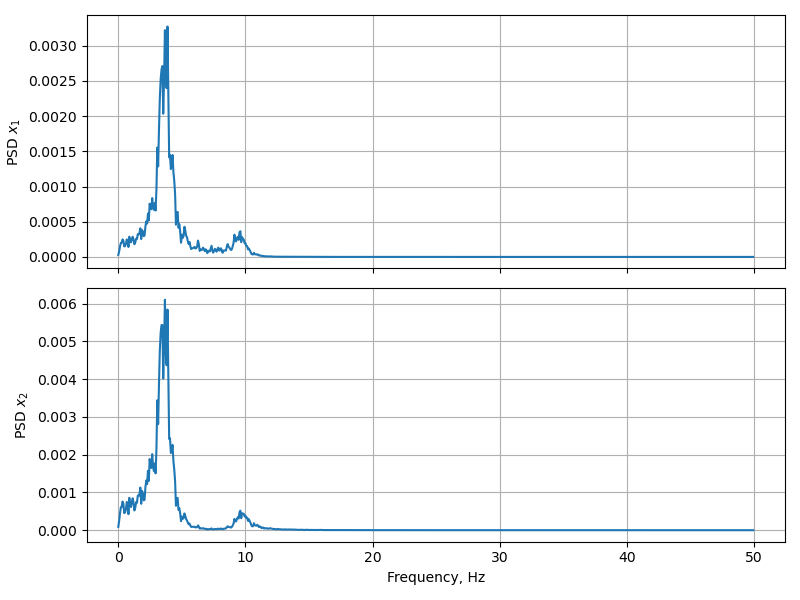

PSD calculation complete.


In [2]:
# Calculate PSDs using Welch's method
def calculate_psd(signals, fs, nperseg=None, noverlap=None):
    """
    Calculate power spectral density for multiple signals.
    
    Parameters:
    -----------
    signals : ndarray
        Array of signals with shape (n_signals, n_samples)
    fs : float
        Sampling frequency
    nperseg : int, optional
        Length of each segment
    noverlap : int, optional
        Number of points to overlap between segments
    
    Returns:
    --------
    freqs : ndarray
        Frequency vector
    psds : ndarray
        PSDs for each signal with shape (n_signals, n_frequencies)
    """
    n_signals = signals.shape[0]
    psds = []
    
    for i in range(n_signals):
        f, psd = signal.welch(
            signals[i],
            fs=fs,
            window='hann',
            nperseg=nperseg,
            noverlap=noverlap,
            detrend='constant',
            return_onesided=False
        )
        psds.append(psd)
    
    return f, np.array(psds)


# Calculate PSDs from response data only
frequencies, psds = calculate_psd(displacements, f_sampling, nperseg=1500)

# Create figure with one subplot for each DOF
fig, axes = plt.subplots(N_DOFS, 1, figsize=(8, 6), sharex=True)

# Plot positive-frequency PSDs
pos_mask = frequencies >= 0
for i in range(N_DOFS):
    axes[i].plot(frequencies[pos_mask], psds[i, pos_mask])
    axes[i].set_ylabel(f'PSD $x_{i+1}$')
    axes[i].grid(True)

axes[-1].set_xlabel('Frequency, Hz')
plt.tight_layout()
plt.show()

print("PSD calculation complete.")

Define functions for PSD fitting and pole extraction.

In [3]:
def rfp_psd_curve_fit(frequencies, psds, numerator_order, denominator_order):
    """
    Implements the RFP method for curve fitting multiple PSD measurements simultaneously.
    
    Parameters:
    -----------
    frequencies : ndarray
        Array of frequency points (rad/s) - MUST be symmetric around zero
    psds : ndarray
        Array of PSD measurements with shape (n_dofs, n_frequencies)
    numerator_order : int
        Order of the numerator polynomial
    denominator_order : int
        Order of the denominator polynomial (should be 2*n_modes)
    
    Returns:
    --------
    tuple
        - a_coeffs_list: List of numerator polynomial coefficients for each DOF
        - b_coeffs: Denominator polynomial coefficients
        - denorm_info: Dictionary with normalization parameters for denormalization
    """
    n_dofs = psds.shape[0]
    n_freqs = frequencies.shape[0]
    
    # CRITICAL: Normalize frequencies to [-1, 1]
    freq_min = frequencies.min()
    freq_max = frequencies.max()
    freq_norm = 2 * (frequencies - freq_min) / (freq_max - freq_min) - 1
    
    print(f"Frequency range: [{freq_min:.2f}, {freq_max:.2f}] rad/s")
    print(f"Normalized range: [{freq_norm.min():.2f}, {freq_norm.max():.2f}]")
    
    # Work in s^2 domain where s = i*omega (using NORMALIZED frequencies)
    s_squared = (1j * freq_norm) ** 2
    
    # Build system matrix [A]{X} = {B}
    # {X} contains [a_1; a_2; ...; a_n; b]
    n_unknowns = n_dofs * (numerator_order + 1) + denominator_order
    n_equations = n_dofs * n_freqs

    # Assemble P block, which is independent of DOF
    P_block = np.zeros((n_freqs, numerator_order + 1), dtype=complex)
    for k in range(numerator_order + 1):
        P_block[:, k] = s_squared ** k

    # Initialize A matrix and B vector
    A_matrix = np.zeros((n_equations, n_unknowns), dtype=complex)
    B_vector = np.zeros(n_equations, dtype=complex)
    
    # Loop over each DOF to fill in the blocks of A and B
    for i in range(n_dofs):
        # Select rows of A and B matrices to fill P, T, and Omega blocks for current DOF
        row_start = i * n_freqs
        row_end = (i + 1) * n_freqs
        
        # Select columns of A matrix to fill P block for current DOF
        col_p_block_start = i * (numerator_order + 1)
        col_p_block_end = (i + 1) * (numerator_order + 1)
        
        # Fill P block into A matrix
        A_matrix[row_start:row_end, col_p_block_start:col_p_block_end] = P_block

        # Select columns of A matrix to fill T block
        col_t_block_start = n_dofs * (numerator_order + 1)
        col_t_block_end = n_dofs * (numerator_order + 1) + denominator_order

        # Calculate T block for current DOF
        T_block = np.zeros((n_freqs, denominator_order), dtype=complex)
        for k in range(denominator_order):
            T_block[:, k] = psds[i] * (s_squared ** k)

        # Fill T block into A matrix
        A_matrix[row_start:row_end, col_t_block_start:col_t_block_end] = -T_block
        
        # Right-hand side: omega vector
        B_vector[row_start:row_end] = psds[i] * (s_squared ** denominator_order)
    
    # Print diagnostics
    print(f"System matrix A shape: {A_matrix.shape}")
    print(f"Condition number of A: {np.linalg.cond(A_matrix):.2e}")
    
    # Solve least square problem (numpy's lstsq uses SVD internally)
    X_solution, residuals, rank, s_values = np.linalg.lstsq(A_matrix, B_vector, rcond=None)
    
    print(f"Matrix rank: {rank} (full rank: {min(A_matrix.shape)})")
    print(f"Residual norm: {np.sqrt(residuals[0]) if len(residuals) > 0 else 'N/A'}")
    
    # Extract numerator coefficients for each DOF
    a_coeffs_list = []
    for i in range(n_dofs):
        row_start = i * (numerator_order + 1)
        row_end = (i + 1) * (numerator_order + 1)
        a_coeffs_list.append(X_solution[row_start:row_end])
    
    # Extract denominator coefficients
    b_coeffs = np.append(X_solution[row_end:], 1.0)  # Add b_n = 1
    
    # Store normalization info for denormalization
    denorm_info = {
        'freq_min': freq_min,
        'freq_max': freq_max
    }
    
    return a_coeffs_list, b_coeffs, denorm_info


def extract_poles_from_psd(b_coeffs, denorm_info):
    """
    Extract system poles from PSD denominator coefficients.
    
    Parameters:
    -----------
    b_coeffs : ndarray
        Denominator polynomial coefficients in s^2 domain (normalized)
    denorm_info : dict
        Dictionary containing 'freq_min' and 'freq_max' for denormalization
    
    Returns:
    --------
    tuple
        - natural_freqs: List of natural frequencies (rad/s)
        - damping_ratios: List of damping ratios
        - pole_groups: List of numpy arrays, each containing either 1 (real pole or unpaired complex pole) 
                       or 2 (conjugate pair) poles
    """
    # Find roots in s^2 domain (normalized)
    mu_roots_norm = np.roots(b_coeffs[::-1])
    
    # Denormalize the roots
    freq_min = denorm_info['freq_min']
    freq_max = denorm_info['freq_max']
    denorm_factor = ((freq_max - freq_min) / 2) ** 2
    mu_roots = mu_roots_norm * denorm_factor
    
    # Convert to s domain: s = sqrt(mu)
    lambda_roots = np.sqrt(mu_roots)
    
    # Initialize lists to store results
    pole_groups = []
    natural_freqs = []
    damping_ratios = []
    
    # Keep track of which poles have been processed
    processed = np.zeros(len(lambda_roots), dtype=bool)
    
    # Process each pole
    for i in range(len(lambda_roots)):
        if processed[i]:
            continue
        
        # Select the current pole
        pole = lambda_roots[i]
        processed[i] = True
        
        # Iterate over remaining poles to find conjugate
        for j in range(len(lambda_roots)):
            if processed[j]:
                continue
            
            # Select candidate pole
            candidate = lambda_roots[j]
            
            # Check if candidate is the complex conjugate of pole
            # Conjugate means: same real part, opposite imaginary part
            if (np.isclose(pole.real, candidate.real) and
                np.isclose(pole.imag, -candidate.imag)):
                
                # Found the conjugate pair!
                pole_groups.append(np.array([pole, candidate]))
                
                # Calculate natural frequency (magnitude of pole)
                nat_freq = np.abs(pole)
                natural_freqs.append(nat_freq)
                
                # Calculate damping ratio: ζ = -Re(λ) / |λ|
                # (absolute value ensures positive damping for stable systems)
                damping_ratios.append(np.abs(pole.real) / nat_freq)
                
                # Mark pole as processed
                processed[j] = True
                break
        
            else:
                # Pole without conjugate - unusual but handle it
                # This shouldn't happen for physical systems but might occur
                # due to numerical issues
                pole_groups.append(np.array([pole]))
                natural_freqs.append(np.abs(pole))
                damping_ratios.append(np.abs(pole.real) / np.abs(pole))
                processed[i] = True
                break
    
    # Sort all results by natural frequency (ascending)
    sort_indices = np.argsort(natural_freqs)
    pole_groups = [pole_groups[i] for i in sort_indices]
    natural_freqs = np.array([natural_freqs[i] for i in sort_indices])
    damping_ratios = np.array([damping_ratios[i] for i in sort_indices])
    
    return natural_freqs, damping_ratios, pole_groups


def calculate_fitted_psd(frequencies, a_coeffs_list, b_coeffs, denorm_info):
    """
    Calculate fitted PSD using polynomial coefficients.
    
    Parameters:
    -----------
    frequencies : ndarray
        Frequency points (rad/s)
    a_coeffs_list : list
        Numerator coefficients for each DOF
    b_coeffs : ndarray
        Denominator coefficients
    denorm_info : dict
        Dictionary containing 'freq_min' and 'freq_max' for normalization
    
    Returns:
    --------
    fitted_psds : ndarray
        Fitted PSDs for each DOF
    """
    # Normalize frequencies using the same transformation as during fitting
    freq_min = denorm_info['freq_min']
    freq_max = denorm_info['freq_max']
    freq_norm = 2 * (frequencies - freq_min) / (freq_max - freq_min) - 1
    
    # Work in s^2 domain with normalized frequencies
    s_squared = (1j * freq_norm) ** 2
    
    n_dofs = len(a_coeffs_list)
    fitted_psds = np.zeros((n_dofs, len(frequencies)))
    
    for i in range(n_dofs):
        numerator = np.polyval(a_coeffs_list[i][::-1], s_squared)
        denominator = np.polyval(b_coeffs[::-1], s_squared)
        fitted_psds[i] = np.real(numerator / denominator)  # PSD should be real
    
    return fitted_psds

Perform identification with fixed model order $n=m=4$.


Frequency range for fitting: [-49.93, 49.93] Hz
Frequency range: [-313.74, 313.74] rad/s
Normalized range: [-1.00, 1.00]
System matrix A shape: (2996, 14)
Condition number of A: 5.88e+08
Matrix rank: 14 (full rank: 14)
Residual norm: 1.8782079834307847e-08


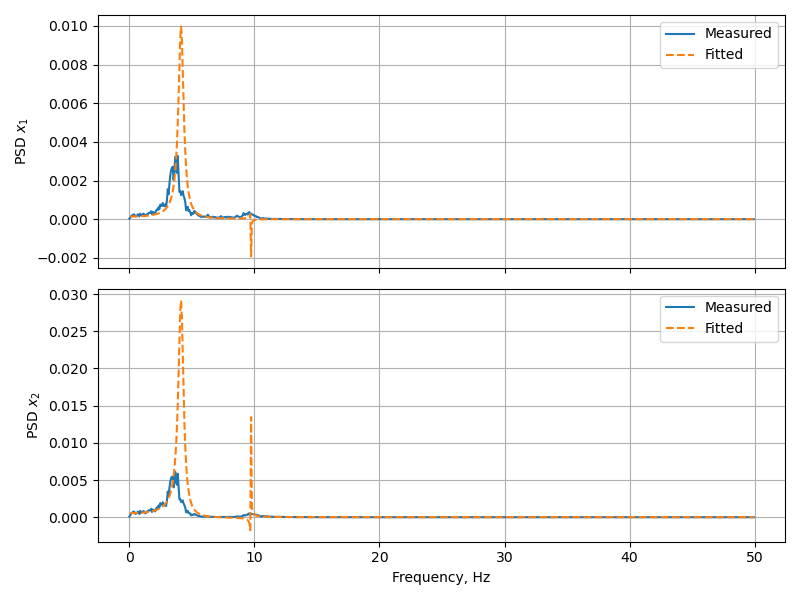


Denominator polynomial coefficients:
  b[0] = 1.244506e-06+0.000000e+00j
  b[1] = 3.931026e-04+0.000000e+00j
  b[2] = 3.622781e-02+0.000000e+00j
  b[3] = 7.425424e-01+0.000000e+00j
  b[4] = 1.000000e+00+0.000000e+00j

Roots μ in NORMALIZED s² domain:
  μ[0] = -6.909286e-01+3.990472e-19j
  μ[1] = -3.793683e-02+7.935752e-19j
  μ[2] = -6.838500e-03+8.450222e-04j
  μ[3] = -6.838500e-03-8.450222e-04j

Roots μ in PHYSICAL s² domain:
  μ[0] = -6.801019e+04+3.927943e-14j
  μ[1] = -3.734238e+03+7.811401e-14j
  μ[2] = -6.731343e+02+8.317809e+01j
  μ[3] = -6.731343e+02-8.317809e+01j

COMPARISON WITH TRUE PARAMETERS

Natural frequencies:
  True:      [23.11178905 61.19013804] rad/s
  Estimated: [ 26.04330866  61.10840807 260.78763783] rad/s
  Percentage Error: [12.68408779 -0.13356723] %

Damping ratios:
  True:      [0.14836852 0.06993401]
  Estimated: [6.14338516e-02 1.04591644e-17 2.88776032e-19]
  Percentage Error: [ -58.59374176 -100.        ] %


In [4]:
# Set polynomial orders
numerator_order = 4
denominator_order = 4  # 2 * n_modes

# Assemble symmetric frequency points excluding Nyquist and zero
symmetric_frequencies = np.hstack([-frequencies[1:frequencies.size//2][::-1], frequencies[1:frequencies.size//2]])
symmetric_angular_frequencies = 2 * np.pi * symmetric_frequencies

# Assemble symmetric PSDs
symmetric_psds = np.hstack([psds[:, 1:psds.shape[1]//2][:, ::-1], psds[:, 1:psds.shape[1]//2]])

# Verify frequencies are symmetric
print(f"\nFrequency range for fitting: "
      f"[{symmetric_angular_frequencies.min()/(2*np.pi):.2f}, "
      f"{symmetric_angular_frequencies.max()/(2*np.pi):.2f}] Hz")

# Perform curve fitting with the corrected function
a_coeffs_list, b_coeffs, denorm_info = rfp_psd_curve_fit(
    symmetric_angular_frequencies,
    symmetric_psds,
    numerator_order,
    denominator_order
)

# Extract poles with the corrected function
natural_frequencies_est, damping_ratios_est, system_poles = extract_poles_from_psd(
    b_coeffs, denorm_info
)

# Calculate fitted PSDs with the corrected function
fitted_psds = calculate_fitted_psd(
    symmetric_angular_frequencies, a_coeffs_list, b_coeffs, denorm_info
)

# Find positive frequency mask for fitted PSDs
symmetric_fres_pos_mask = symmetric_frequencies >= 0

# Plot comparison
fig, axes = plt.subplots(N_DOFS, 1, figsize=(8, 6), sharex=True)
for i in range(N_DOFS):
    axes[i].plot(frequencies[pos_mask], psds[i, pos_mask], label='Measured')
    axes[i].plot(symmetric_frequencies[symmetric_fres_pos_mask], fitted_psds[i, symmetric_fres_pos_mask], label='Fitted', linestyle='--')
    axes[i].set_ylabel(f'PSD $x_{i+1}$')
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel('Frequency, Hz')
plt.tight_layout()
plt.show()

# Print results
print(f"\nDenominator polynomial coefficients:")
for i, coef in enumerate(b_coeffs):
    print(f"  b[{i}] = {coef:.6e}")

# Check the roots μ in s² domain (should be complex conjugate pairs)
mu_roots_norm = np.roots(b_coeffs[::-1])
print(f"\nRoots μ in NORMALIZED s² domain:")
for i, root in enumerate(mu_roots_norm):
    print(f"  μ[{i}] = {root:.6e}")

# Denormalized roots
freq_min = denorm_info['freq_min']
freq_max = denorm_info['freq_max']
denorm_factor = ((freq_max - freq_min) / 2) ** 2
mu_roots = mu_roots_norm * denorm_factor
print(f"\nRoots μ in PHYSICAL s² domain:")
for i, root in enumerate(mu_roots):
    print(f"  μ[{i}] = {root:.6e}")

# Calculate percentage errors between true and estimated parameters
freq_errors = np.zeros_like(natural_frequencies_true)
damping_errors = np.zeros_like(damping_ratios_true)
for i in range(len(natural_frequencies_true)):
    freq_errors[i] = (natural_frequencies_est[i] - natural_frequencies_true[i]) / natural_frequencies_true[i] * 100
    damping_errors[i] = (damping_ratios_est[i] - damping_ratios_true[i]) / damping_ratios_true[i] * 100

# Compare with true parameters
print("\n" + "="*60)
print("COMPARISON WITH TRUE PARAMETERS")
print("="*60)
print(f"\nNatural frequencies:")
print(f"  True:      {natural_frequencies_true} rad/s")
print(f"  Estimated: {natural_frequencies_est} rad/s")
print(f"  Percentage Error: {freq_errors} %")
print(f"\nDamping ratios:")
print(f"  True:      {damping_ratios_true}")
print(f"  Estimated: {damping_ratios_est}")
print(f"  Percentage Error: {damping_errors} %")

Perform identification in reduced frequency range.

Frequency range: [-87.96, 87.96] rad/s
Normalized range: [-1.00, 1.00]
System matrix A shape: (840, 14)
Condition number of A: 1.46e+06
Matrix rank: 14 (full rank: 14)
Residual norm: 2.588714031565049e-06


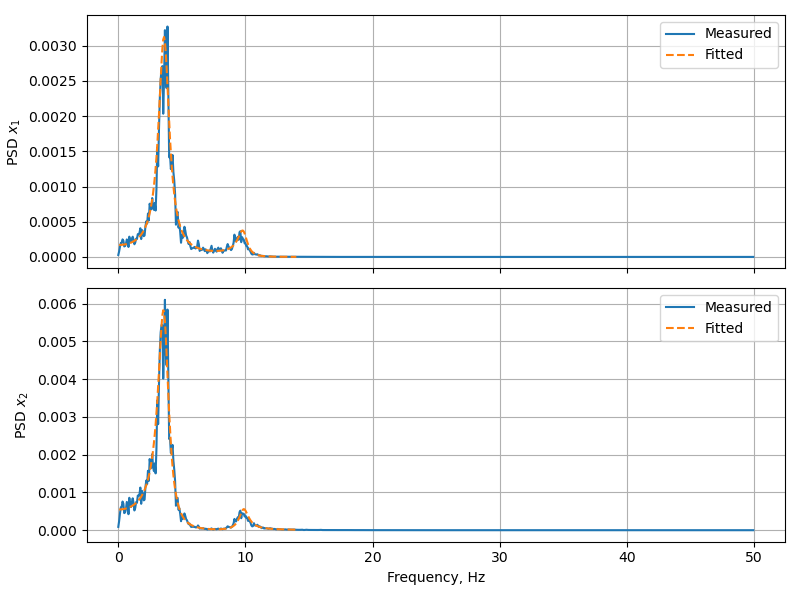


Denominator polynomial coefficients:
  b[0] = 1.118890e-03+0.000000e+00j
  b[1] = 3.630219e-02+0.000000e+00j
  b[2] = 3.778526e-01+0.000000e+00j
  b[3] = 1.116183e+00+0.000000e+00j
  b[4] = 1.000000e+00+0.000000e+00j

Roots μ in NORMALIZED s² domain:
  μ[0] = -4.933041e-01+4.588306e-02j
  μ[1] = -4.933041e-01-4.588306e-02j
  μ[2] = -6.478762e-02+1.900037e-02j
  μ[3] = -6.478762e-02-1.900037e-02j

Roots μ in PHYSICAL s² domain:
  μ[0] = -3.817073e+03+3.550326e+02j
  μ[1] = -3.817073e+03-3.550326e+02j
  μ[2] = -5.013117e+02+1.470205e+02j
  μ[3] = -5.013117e+02-1.470205e+02j

COMPARISON WITH TRUE PARAMETERS

Natural frequencies:
  True:      [23.11178905 61.19013804] rad/s
  Estimated: [22.85663015 61.91565907] rad/s
  Percentage Error: [-1.10402056  1.18568294] %

Damping ratios:
  True:      [0.14836852 0.06993401]
  Estimated: [0.1421531  0.04635582]
  Percentage Error: [ -4.18917324 -33.71490245] %


In [5]:
numerator_order = 4
denominator_order = 4  # 2 * n_modes

# CRITICAL: Restrict to frequency range containing the modes
# Your modes are around 4 Hz and 10 Hz, so use [-14, 14] Hz range
freq_mask = (symmetric_frequencies >= -14) & (symmetric_frequencies <= 14)
frequency_masked = symmetric_frequencies[freq_mask]
angular_frequency_masked = symmetric_angular_frequencies[freq_mask]
psds_masked = symmetric_psds[:, freq_mask]

# Perform curve fitting with the corrected function
a_coeffs_list, b_coeffs, denorm_info = rfp_psd_curve_fit(
    angular_frequency_masked,
    psds_masked,
    numerator_order,
    denominator_order
)

# Extract poles with the corrected function
natural_frequencies_est, damping_ratios_est, system_poles = extract_poles_from_psd(
    b_coeffs, denorm_info
)

# Calculate fitted PSDs with the corrected function
fitted_psds = calculate_fitted_psd(
    angular_frequency_masked, a_coeffs_list, b_coeffs, denorm_info
)

# Find positive frequency mask for fitted PSDs
symmetric_fres_pos_mask = frequency_masked >= 0

# Plot comparison
fig, axes = plt.subplots(N_DOFS, 1, figsize=(8, 6), sharex=True)
for i in range(N_DOFS):
    axes[i].plot(frequencies[pos_mask], psds[i, pos_mask], label='Measured')
    axes[i].plot(frequency_masked[symmetric_fres_pos_mask], fitted_psds[i, symmetric_fres_pos_mask], label='Fitted', linestyle='--')
    axes[i].set_ylabel(f'PSD $x_{i+1}$')
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel('Frequency, Hz')
plt.tight_layout()
plt.show()

# Print results
print(f"\nDenominator polynomial coefficients:")
for i, coef in enumerate(b_coeffs):
    print(f"  b[{i}] = {coef:.6e}")

# Check the roots μ in s² domain (should be complex conjugate pairs)
mu_roots_norm = np.roots(b_coeffs[::-1])
print(f"\nRoots μ in NORMALIZED s² domain:")
for i, root in enumerate(mu_roots_norm):
    print(f"  μ[{i}] = {root:.6e}")

# Denormalized roots
freq_min = denorm_info['freq_min']
freq_max = denorm_info['freq_max']
denorm_factor = ((freq_max - freq_min) / 2) ** 2
mu_roots = mu_roots_norm * denorm_factor
print(f"\nRoots μ in PHYSICAL s² domain:")
for i, root in enumerate(mu_roots):
    print(f"  μ[{i}] = {root:.6e}")

# Calculate percentage errors between true and estimated parameters
for i in range(len(natural_frequencies_true)):
    freq_errors[i] = (natural_frequencies_est[i] - natural_frequencies_true[i]) / natural_frequencies_true[i] * 100
    damping_errors[i] = (damping_ratios_est[i] - damping_ratios_true[i]) / damping_ratios_true[i] * 100

# Compare with true parameters
print("\n" + "="*60)
print("COMPARISON WITH TRUE PARAMETERS")
print("="*60)
print(f"\nNatural frequencies:")
print(f"  True:      {natural_frequencies_true} rad/s")
print(f"  Estimated: {natural_frequencies_est} rad/s")
print(f"  Percentage Error: {freq_errors} %")
print(f"\nDamping ratios:")
print(f"  True:      {damping_ratios_true}")
print(f"  Estimated: {damping_ratios_est}")
print(f"  Percentage Error: {damping_errors} %")